# Shallow Water via DLRA + DEIM (KSL integrator)

Vector-invariant shallow water equations on a doubly-periodic grid, integrated
in low-rank form with the interpolatory projector-splitting (KSL) integrator and
DEIM/ARP index selection.

In [1]:
# Loads the full DLRA + SWM stack through the single entry file.
include("./SWM/SWM.jl")

using Plots
using LinearAlgebra
using .LowRank
using .InitialConditions
using .SWERhs
using .KSLMatrixSolver

## Grid and physical parameters

In [2]:
N     = 128
radz  = 6371.22e3
grav  = 9.80616
omega = 7.292e-5
pcori = 2 * omega          # constant Coriolis parameter f
H0    = 10e3
Lx    = 2π * radz
dx    = Lx / N
U0    = 20.0

# CFL-limited explicit timestep (gravity-wave speed sqrt(g*H0))
dt = 0.45 * dx / sqrt(grav * H0)

params = SWEParams(dx=dx, grav=grav, fcor=pcori)
println("N=$N  dx=$(round(dx)) m  dt=$(round(dt)) s")

N=128  dx=312747.0 m  dt=449.0 s


## Initial condition

Geostrophically-balanced zonal jet. Each field is exactly low-rank.

rank(u) = 1
rank(v) = 1
rank(h) = 1


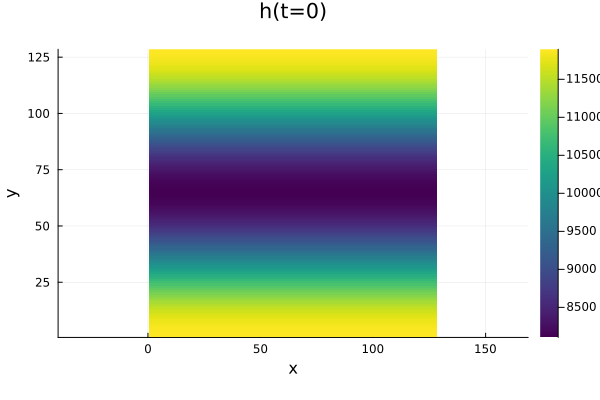

In [3]:
u, v, h = get_lr_geostrophic(N, dx; U0=U0, grav=grav, pcori=pcori, H0=H0)

println("rank(u) = ", LowRank.rank(u))
println("rank(v) = ", LowRank.rank(v))
println("rank(h) = ", LowRank.rank(h))

heatmap(dense(h)', aspect_ratio=1, c=:viridis, title="h(t=0)",
        xlabel="x", ylabel="y")

## Time integration

One `ksl_step` advances the field vector `[u, v, h]` by `dt`. The RHS holds a
frozen snapshot of all three fields; oversampling `k = rank + Δ` stabilises the
DEIM projection.

In [4]:
nsteps    = 200
oversamp  = 4          # DEIM oversampling beyond each field's rank
rmax      = 20         # cap index-set size at the grid size anyway

Ys    = [u, v, h]
mass0 = sum(dense(Ys[3]))

@time for s in 1:nsteps
    G  = swe_rhs(Ys[1], Ys[2], Ys[3], params)
    kK = [min(N, LowRank.rank(Y) + oversamp) for Y in Ys]
    global Ys = ksl_step(Ys, G, (s-1)*dt, dt, LieTrotter(), RK4(), kK, kK)
end

uf, vf, hf = dense.(Ys)
println("after $nsteps steps:")
println("  ranks       = ", [LowRank.rank(Y) for Y in Ys])
println("  mass drift  = ", abs(sum(hf) - mass0) / abs(mass0))
println("  max|u|      = ", maximum(abs, uf))
println("  h ∈ [", round(minimum(hf)), ", ", round(maximum(hf)), "]")

  5.007449 seconds (7.72 M allocations: 1.426 GiB, 8.93% gc time, 94.73% compilation time)
after 200 steps:
  ranks       = [1, 1, 1]
  mass drift  = 8.451909112536666e-5
  max|u|      = 20.388805718531565
  h ∈ [8104.0, 11899.0]


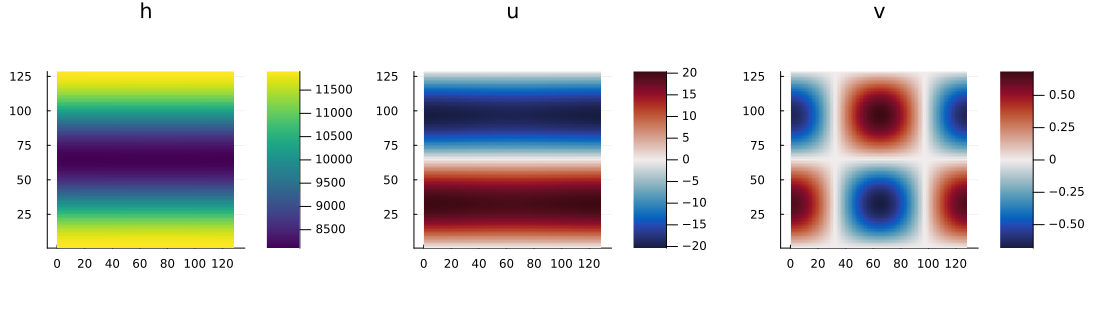

In [5]:
p1 = heatmap(hf', aspect_ratio=1, c=:viridis, title="h")
p2 = heatmap(uf', aspect_ratio=1, c=:balance, title="u")
p3 = heatmap(vf', aspect_ratio=1, c=:balance, title="v")
plot(p1, p2, p3, layout=(1,3), size=(1100, 320))